## EDA

In [4]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from  data_profiling import ProfileReport
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [5]:
file_path = '../data/raw/dataset.csv'
df = pd.read_csv(file_path)

Visualisation de dataset

In [6]:
df.head()

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,C10002,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,C10003,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,C10004,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,C10005,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


In [7]:
df.dtypes

CUST_ID                    object
BALANCE                   float64
PURCHASES                 float64
ONEOFF_PURCHASES          float64
INSTALLMENTS_PURCHASES    float64
CASH_ADVANCE              float64
CREDIT_LIMIT              float64
PAYMENTS                  float64
dtype: object

In [8]:
df.describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


In [9]:
df.describe(include='object')

,CUST_ID
count,8950
unique,8950
top,C10001
freq,1


In [10]:
# profile = ProfileReport(df, title='CardProfiler', explorative=True)
# profile.to_file("cardprofiler.html")

In [11]:
df.isna().sum().reset_index().sort_values(by=0,ascending=False)

,index,0
6,CREDIT_LIMIT,1
0,CUST_ID,0
2,PURCHASES,0
1,BALANCE,0
3,ONEOFF_PURCHASES,0
4,INSTALLMENTS_PURCHASES,0
5,CASH_ADVANCE,0
7,PAYMENTS,0


In [12]:
df.duplicated().sum()
# il n'existe pas des lignes dupliques

np.int64(0)

## Visualisation des données

### coefficient de corrélation de Pearson
- mesure l'asymétrie d'une distribution à partir de la relation entre la moyenne, la médiane et l'écart type. Si la moyenne est supérieure à la médiane, le coefficient est positif, indiquant une asymétrie à droite ; une valeur négative indique une asymétrie à gauche.
### Asymétrie (Skewness)
- Une valeur d'asymétrie positive indique que la distribution est asymétrique à droite, ce qui signifie une queue plus longue du côté droit.

- Comme la moyenne se situe à droite de la médiane et du mode, la distribution est asymétrique positive, ce qui confirme les résultats numériques d'asymétrie.

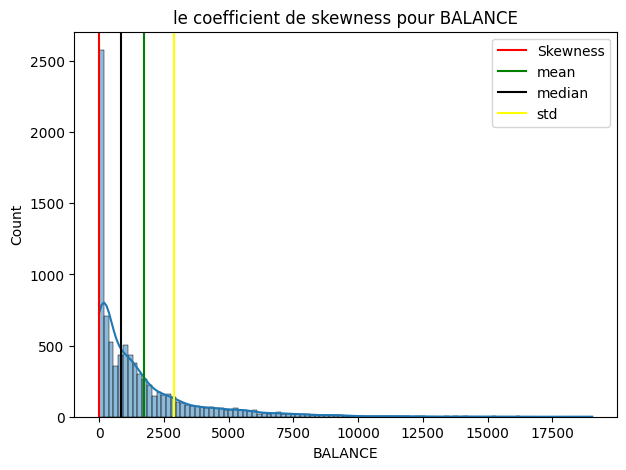

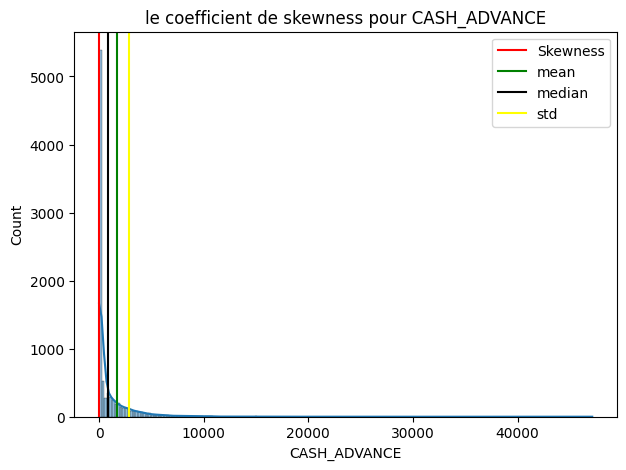

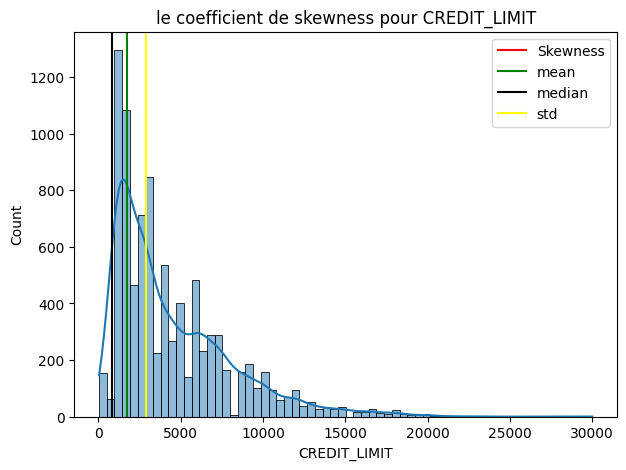

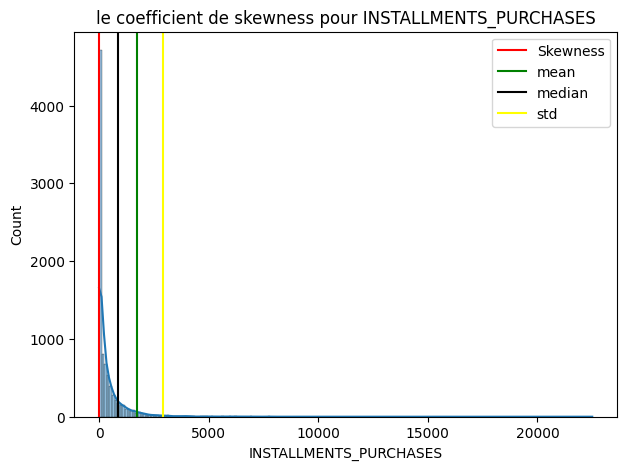

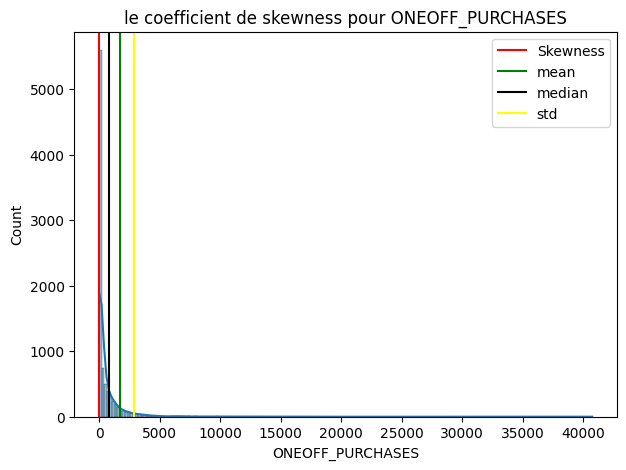

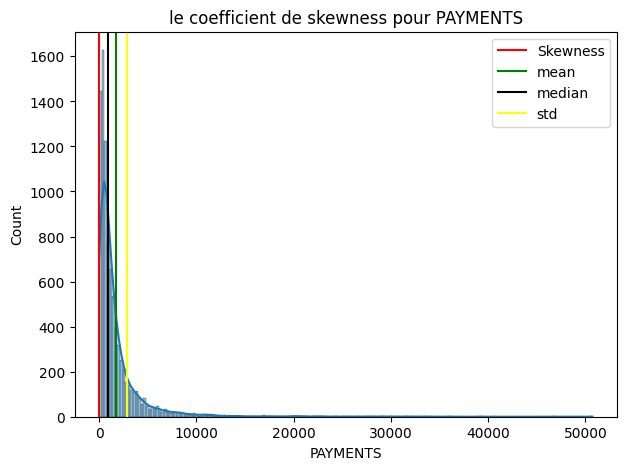

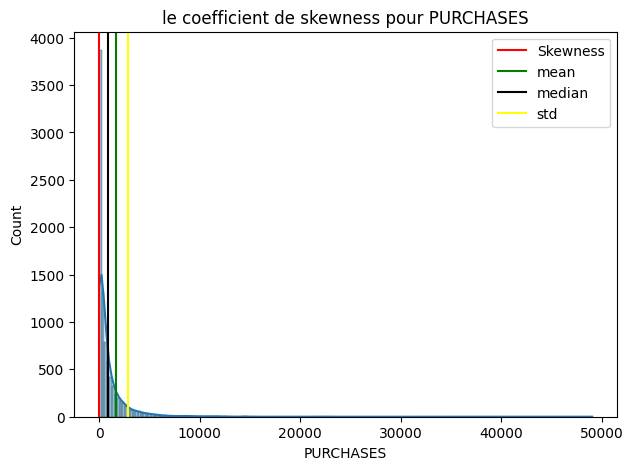

In [13]:
for col in df.columns.difference(other=['CUST_ID']):
      Skewness = skew(df[col], axis=0, bias=True)
      mean = df['PAYMENTS'].mean()
      median = df['PAYMENTS'].median()
      std = df['PAYMENTS'].std()
      pearson_skewness = (3* (mean - median)/std)

      plt.figure(figsize=(7, 5))
      sns.histplot(df[col], kde=True)
      plt.axvline(Skewness, label='Skewness', color='red')
      plt.axvline(mean, label='mean', color='green')
      plt.axvline(median, label='median', color='black')
      plt.axvline(std, label='std', color='yellow')
      plt.title(f"le coefficient de skewness pour {col}")
      plt.legend()
      plt.show()
      

#### Heatmap de la matrice de corrélation

Nous constatant que il y a plusieurs correlation entre les variables:
- BALANCE et CASH_ADVANCE
- INSTALLMENTS_PURCHASES et PURCHASES
- ONEOFF_PURCHASES et PURCHASES
- PAYEMENT et PURCHASES

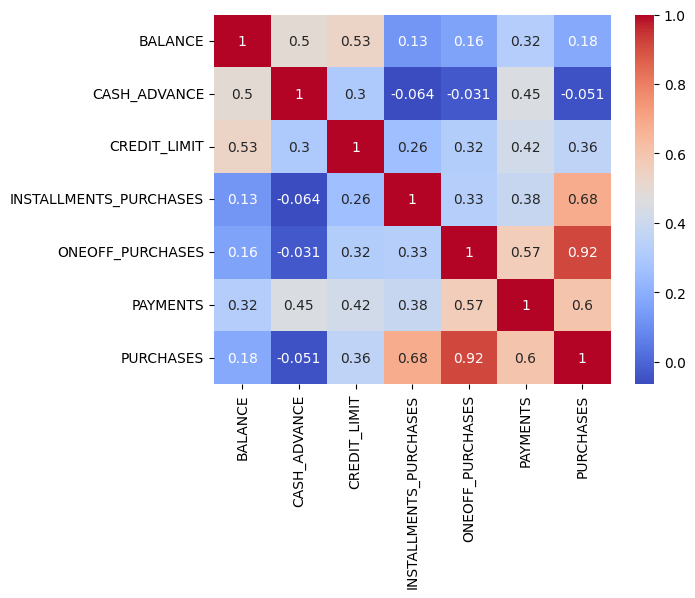

In [14]:
sns.heatmap(df[df.columns.difference(other=['CUST_ID'])].corr(), annot=True, cmap='coolwarm')
plt.show()

### Boxplots (boîtes à moustaches)

L'existance des valeurs aberants ne necessite pas le faite de les supprimer car le domaine banquaire necessite leur existance

In [15]:
Q1, Q3 = np.percentile(df[df.columns.difference(other=['CUST_ID'])], [25, 75] )
IQR = Q3 - Q1
upper_born = Q3 + 1.5*IQR
lower_born = Q1 - 1.5*IQR


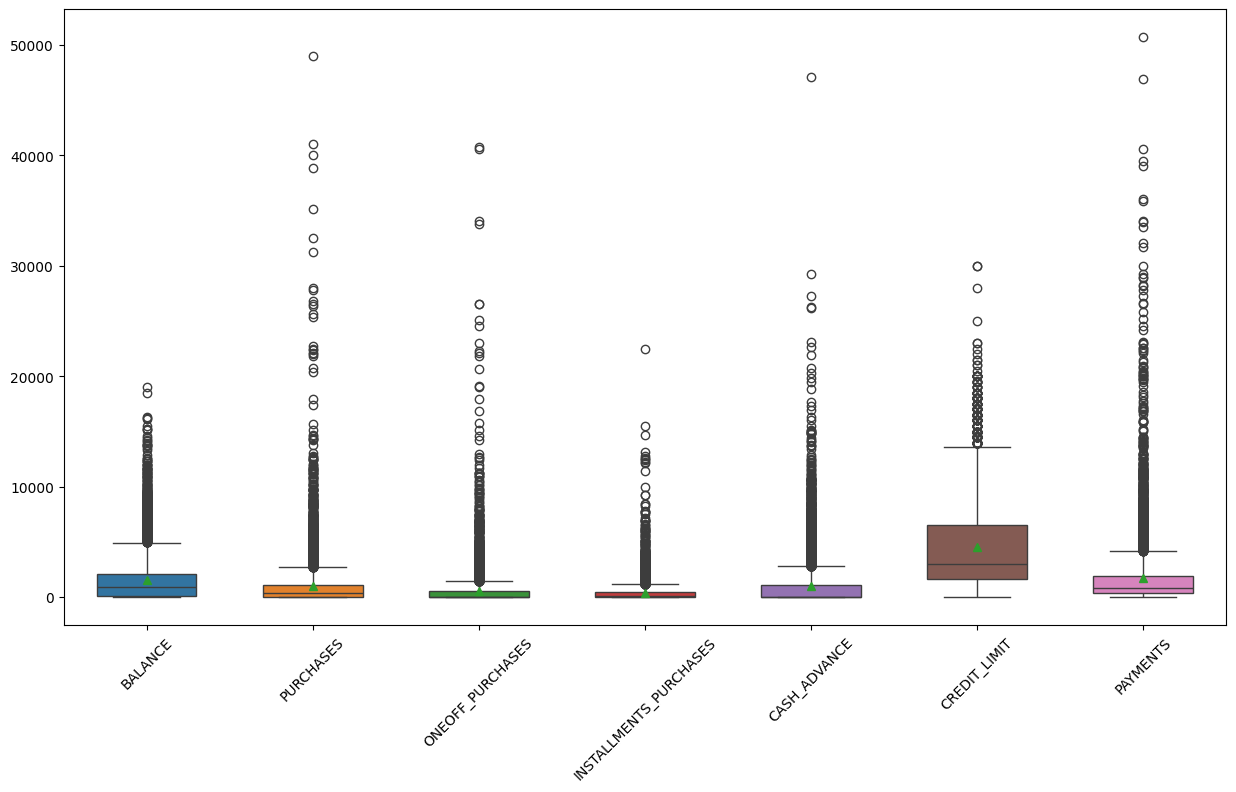

In [16]:
plt.figure(figsize=(15, 8))
ax = sns.boxplot(df, showmeans=True,vert=True,          
    widths=0.6)
plt.setp(ax.get_xticklabels(), rotation=45)
plt.show()

### Feature Story 2 : Prétraitement des données

In [17]:
df_clean = df.copy()

Remplacement de la valeur manquante pour le CREDIT LIMIT PAR LA MEDIANE

### Nettoyage minimal 

In [18]:
df_clean.loc[df_clean['CREDIT_LIMIT'].isna(),'CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].median()

### Préparation clustering

In [19]:
df_prepare_clustering = df_clean[df_clean.columns.difference(other=['CUST_ID'])].copy()


### Visualisation avant la transformation logarithmique

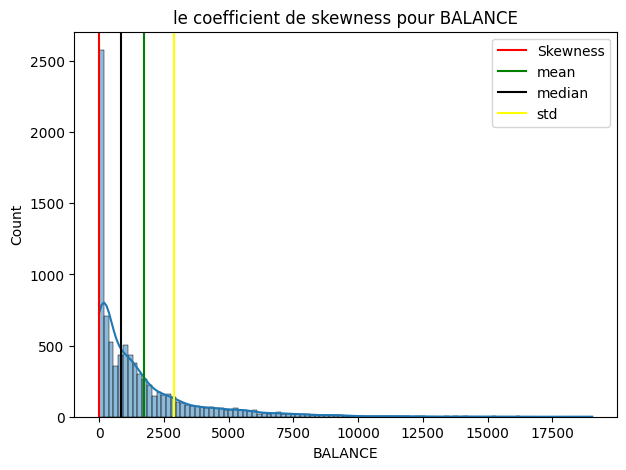

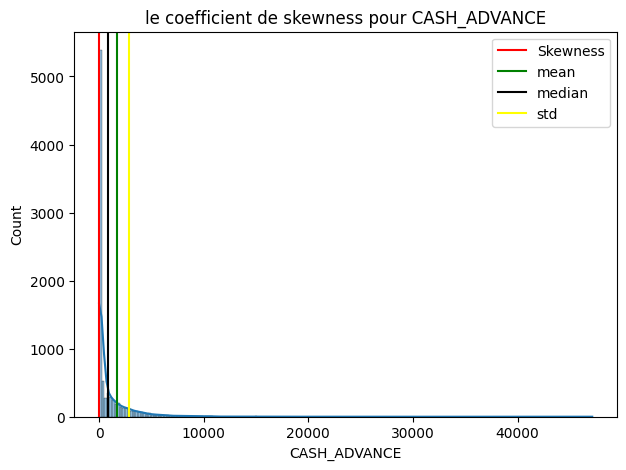

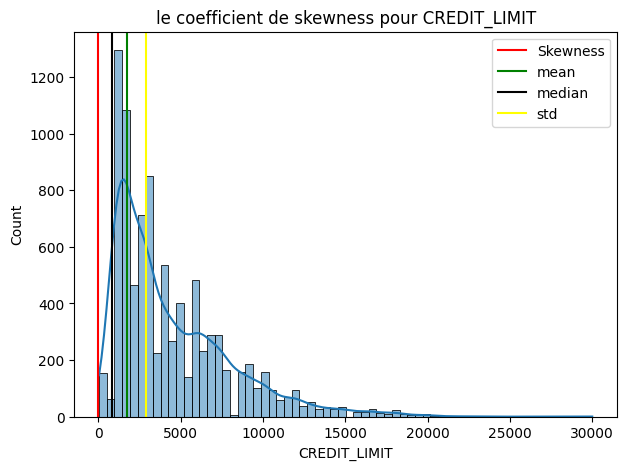

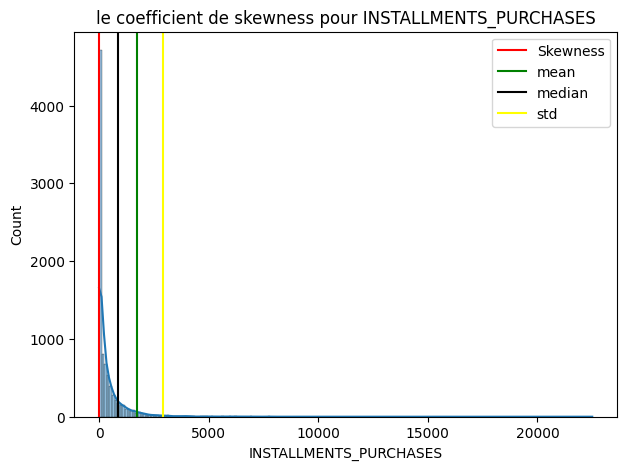

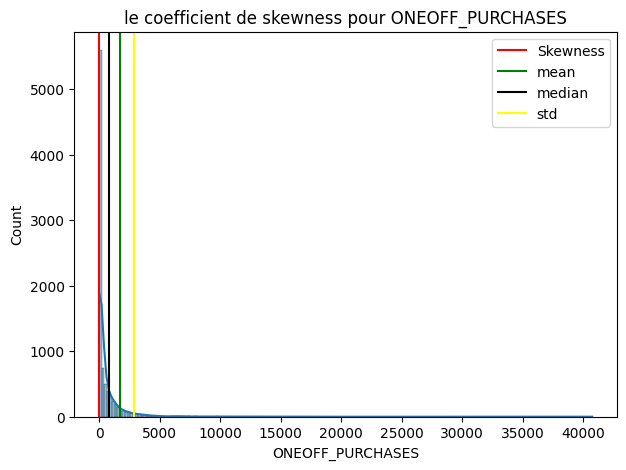

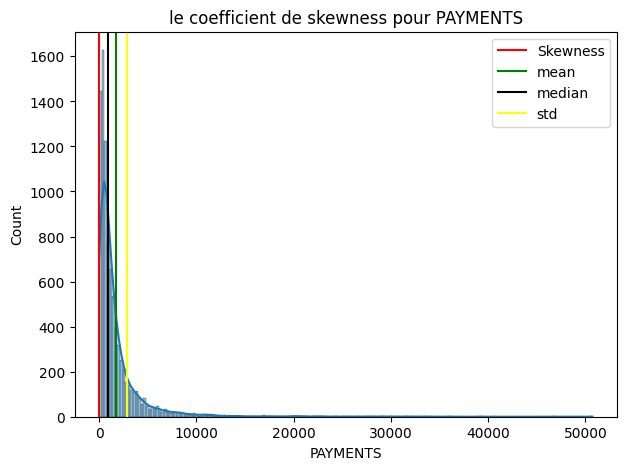

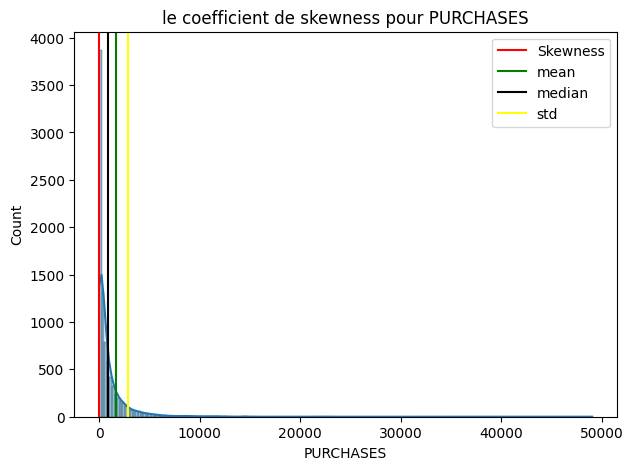

In [20]:
for col in  df_prepare_clustering.columns:
      Skewness = skew(df_prepare_clustering[col], axis=0, bias=True)
      mean = df_prepare_clustering['PAYMENTS'].mean()
      median = df_prepare_clustering['PAYMENTS'].median()
      std = df_prepare_clustering['PAYMENTS'].std()
      pearson_skewness = (3* (mean - median)/std)

      
      plt.figure(figsize=(7, 5))
      sns.histplot(df_prepare_clustering[col], kde=True)
      plt.axvline(Skewness, label='Skewness', color='red')
      plt.axvline(mean, label='mean', color='green')
      plt.axvline(median, label='median', color='black')
      plt.axvline(std, label='std', color='yellow')
      plt.title(f"le coefficient de skewness pour {col}")
      plt.legend()
      plt.show()

### Visualisation apres la tranformation ligarithmique
- J'ai appliqué cette transformation parce que les distributions étaient fortement asymétriques, puis j'ai comparé le skewness avant/après afin de vérifier son effet.

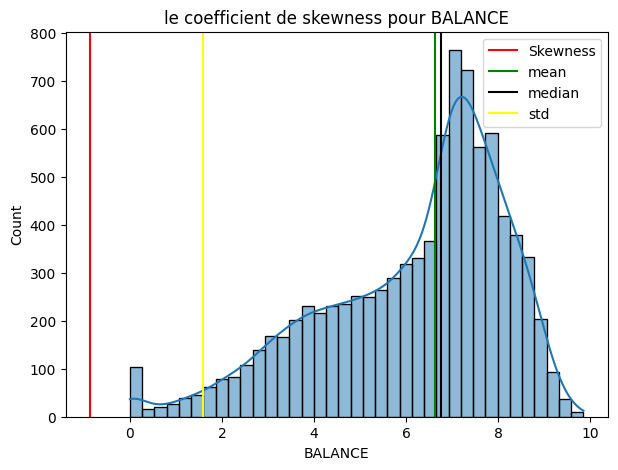

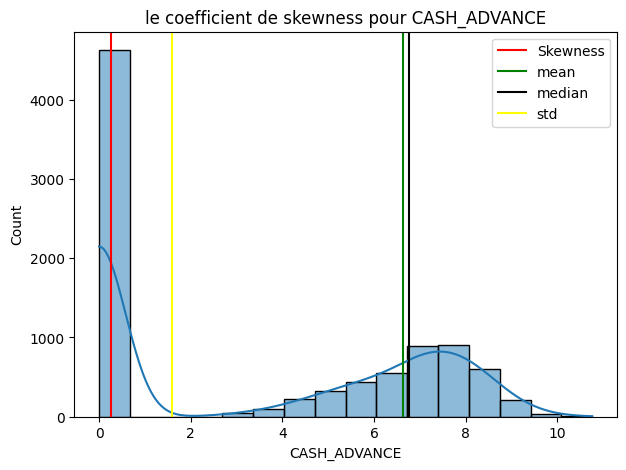

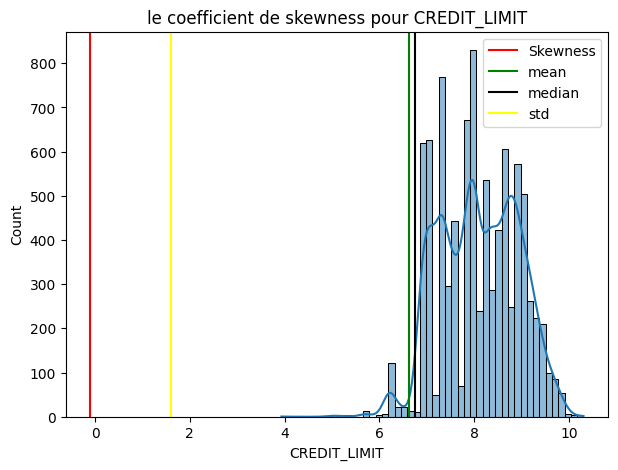

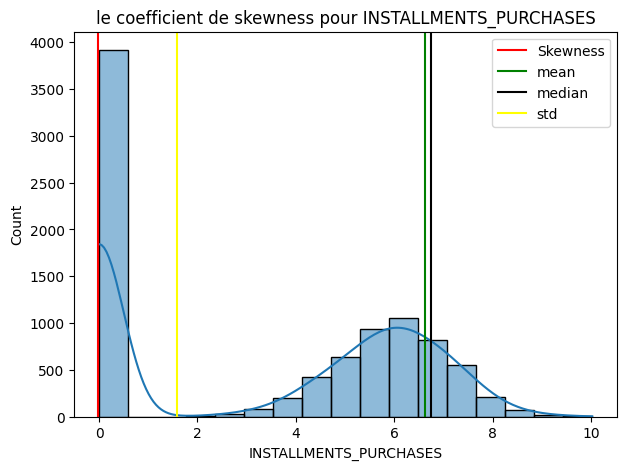

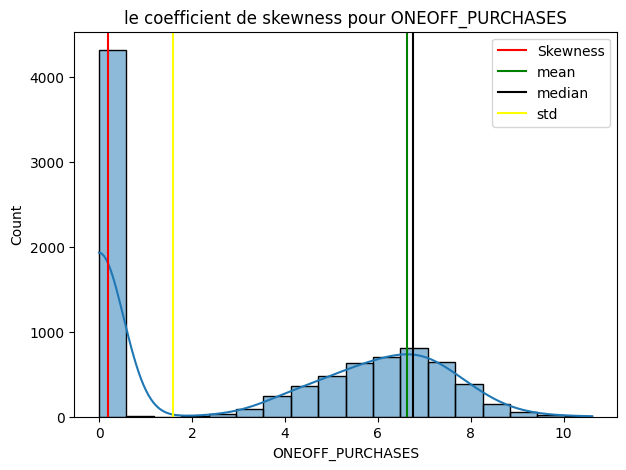

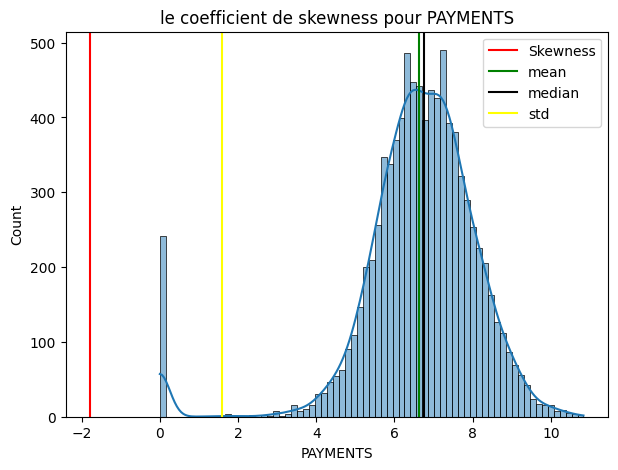

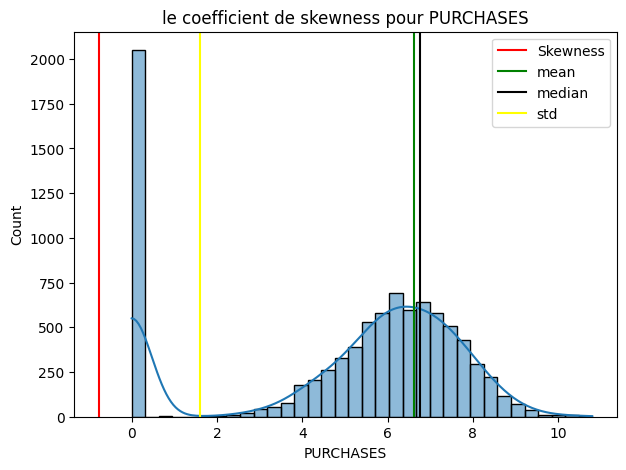

In [21]:
x_log = np.log1p(df_prepare_clustering)
for col in x_log.columns:
      
      new_Skewness = skew(x_log[col], axis=0, bias=True)
      new_mean = x_log['PAYMENTS'].mean()
      new_median = x_log['PAYMENTS'].median()
      new_std = x_log['PAYMENTS'].std()
      new_pearson_skewness = (3* (new_mean - new_median)/new_std)

      plt.figure(figsize=(7, 5))
      sns.histplot(x_log[col], kde=True)
      plt.axvline(new_Skewness, label='Skewness', color='red')
      plt.axvline(new_mean, label='mean', color='green')
      plt.axvline(new_median, label='median', color='black')
      plt.axvline(new_std, label='std', color='yellow')
      plt.title(f"le coefficient de skewness pour {col}")
      plt.legend()
      plt.show()

#### Standardisation (StandardScaler), toujours après le log 

In [22]:
scaler = StandardScaler()

#### DATAFRAME PREPARE CLUSTRING AVANT LA STANDARDISATION

In [23]:
x_log

,BALANCE,CASH_ADVANCE,CREDIT_LIMIT,INSTALLMENTS_PURCHASES,ONEOFF_PURCHASES,PAYMENTS,PURCHASES
0,3.735304,0.000000,6.908755,4.568506,0.000000,5.312231,4.568506
1,8.071989,8.770896,8.853808,0.000000,0.000000,8.319725,0.000000
2,7.822504,0.000000,8.922792,0.000000,6.651791,6.434654,6.651791
3,7.419183,5.331694,8.922792,0.000000,7.313220,0.000000,7.313220
4,6.707735,0.000000,7.090910,0.000000,2.833213,6.521114,2.833213
...,...,...,...,...,...,...,...
8945,3.384170,0.000000,6.908755,5.677165,0.000000,5.788719,5.677165
8946,3.004851,0.000000,6.908755,5.707110,0.000000,5.623517,5.707110
8947,3.194529,0.000000,6.908755,4.979489,0.000000,4.410016,4.979489
8948,2.671218,3.625907,6.216606,0.000000,0.000000,3.980615,0.000000


#### DATAFRAME PREPARE CLUSTRING APRES LA STANDARDISATION

In [24]:
x_scater = scaler.fit_transform(x_log)
x_scater

array([[-1.20521818, -0.93073294, -1.44716254, ..., -0.98708958,
        -0.82448405, -0.11353236],
       [ 0.94891762,  1.52878819,  0.92606022, ..., -0.98708958,
         1.06503312, -1.67985462],
       [ 0.82499258, -0.93073294,  1.01022904, ...,  1.06202168,
        -0.11929988,  0.60072652],
       ...,
       [-1.4738341 , -0.93073294, -1.44716254, ..., -0.98708958,
        -1.39131795,  0.02737383],
       [-1.73377525,  0.08603831, -2.29167555, ..., -0.98708958,
        -1.66109743, -1.67985462],
       [-0.11830096,  0.42995349, -1.22490927, ...,  1.16861854,
        -1.54747543,  0.71936468]], shape=(8950, 7))

### Analyse en Composantes Principales
- Visualisation de données
- Compresssion de données

PCA cherche donc à créer de nouvelles dimensions qui résument l'information présente dans les anciennes.

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca = PCA(n_components=7)

In [27]:
X_pca = pca.fit_transform(x_scater)

In [28]:
variance_expliquee =pca.explained_variance_ratio_

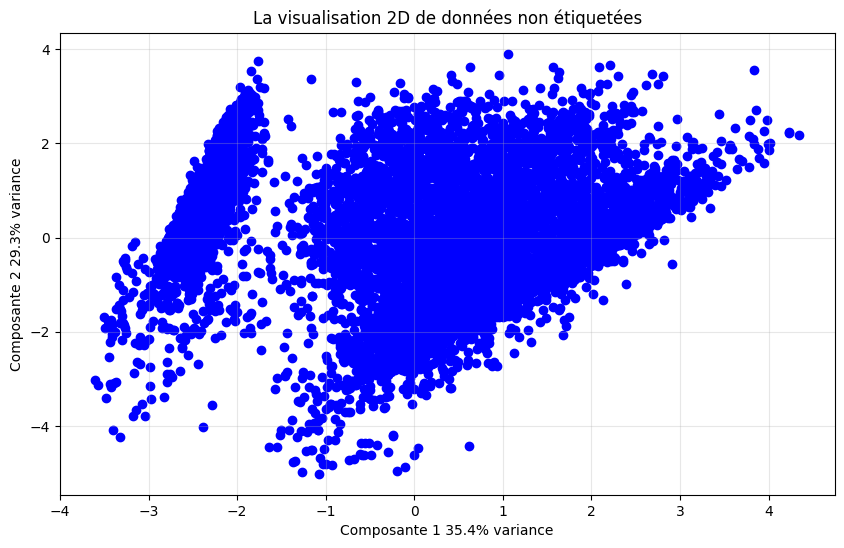

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:, 1], color='blue')
plt.xlabel(f'Composante 1 {variance_expliquee[0]:.1%} variance')
plt.ylabel(f'Composante 2 {variance_expliquee[1]:.1%} variance')
plt.title('La visualisation 2D de données non étiquetées')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
variance_cumule =np.cumsum(pca.explained_variance_ratio_)

Text(0.5, 1.0, 'Le % de variance conservée')

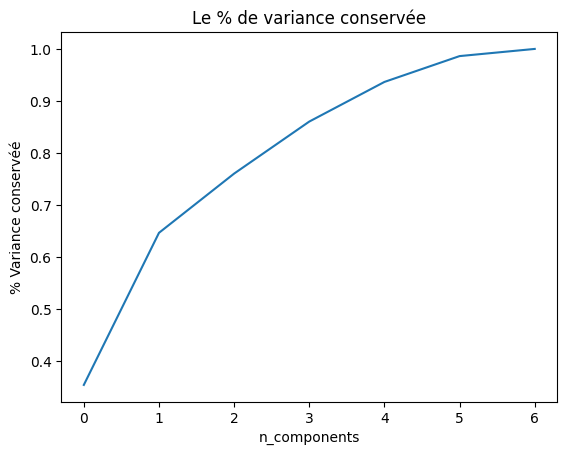

In [31]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('n_components')
plt.ylabel('% Variance conservéé')
plt.title('Le % de variance conservée')

In [32]:
best_n_componenet = np.argmax(np.cumsum(variance_expliquee) > 0.8) + 1
print(f' le best n_component : {best_n_componenet} pour une variance cumulée > 80%' )


 le best n_component : 4 pour une variance cumulée > 80%


In [33]:
df_pca_summary = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(variance_expliquee))],
    'Variance explique (%)': variance_expliquee.round(2),
    'Variance cumule (%)': variance_cumule.round(2)
})
df_pca_summary

,Composante,Variance explique (%),Variance cumule (%)
0,PC1,0.35,0.35
1,PC2,0.29,0.65
2,PC3,0.11,0.76
3,PC4,0.10,0.86
4,PC5,0.08,0.94
5,PC6,0.05,0.99
6,PC7,0.01,1.00


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [35]:
n_composants_list = range(2,6)
k_list = range(2,8)

In [36]:
resluts_kmeans = []

In [37]:
for n_component in n_composants_list:
      #PCA AVEC LE NOMBRE DE COMPOSANTS ACTUEL
      pca = PCA(n_components=n_component)

      X_pca = pca.fit_transform(x_scater)

      for k in k_list:
          #CREER LE MODEL K_MEANS
          kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
          #ENTRAINER K_MEANS
          labels = kmeans.fit_predict(X_pca)
          #RECUPERER INERTIA
          inertia  = kmeans.inertia_
          #CALCUL SILHOUETTE
          silhouette = silhouette_score(X_pca,labels )

          #SAUVGARDE DES RESULTATS
          resluts_kmeans.append({
               "n_components" : n_component,
               "k" : k,
               "inertia" : inertia,
               "silhouette":silhouette
          })
results_kmeans_df = pd.DataFrame(resluts_kmeans)
results_kmeans_df


,n_components,k,inertia,silhouette
0,2,2,23546.231773,0.430922
1,2,3,13250.771262,0.448719
2,2,4,10420.610260,0.422778
3,2,5,8247.578818,0.410069
4,2,6,6687.617382,0.394525
5,2,7,5637.302350,0.398414
6,3,2,30684.841554,0.367888
7,3,3,20211.664628,0.382580
8,3,4,16455.107516,0.388720
9,3,5,13787.086186,0.390832


In [38]:
best_kmeans = results_kmeans_df.loc[results_kmeans_df['silhouette'].idxmax()]
print("best_kmeans", best_kmeans)

best_kmeans n_components        2.000000
k                   3.000000
inertia         13250.771262
silhouette          0.448719
Name: 1, dtype: float64


In [39]:
heatmap_data = results_kmeans_df.pivot(index="n_components", columns="k", values='silhouette')

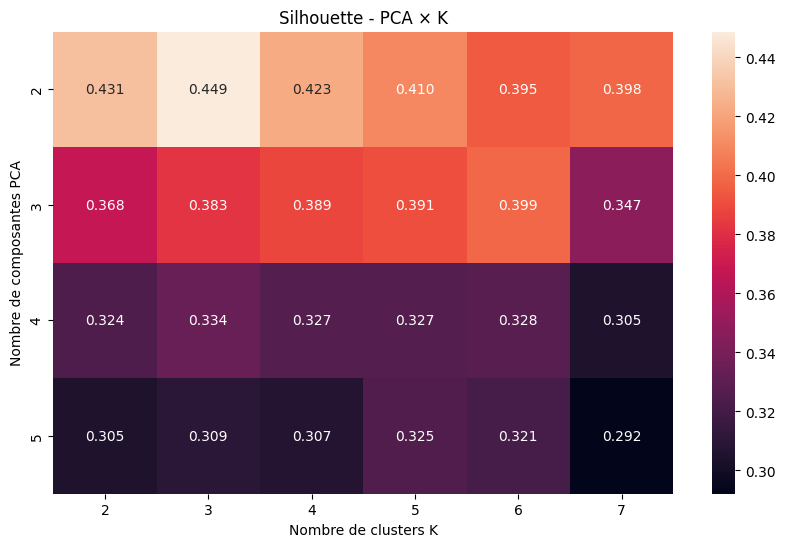

In [40]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f"
)

plt.title("Silhouette - PCA × K")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Nombre de composantes PCA")

plt.show()

l'Elbow

In [41]:
pca = PCA(n_components=2)
X_pca_2 = pca.fit_transform(x_scater)

In [42]:
inertias = []

for k in k_list:
      kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

      kmeans.fit(X_pca_2)

      inertias.append(kmeans.inertia_)

Text(0.5, 1.0, 'Methode du coude')

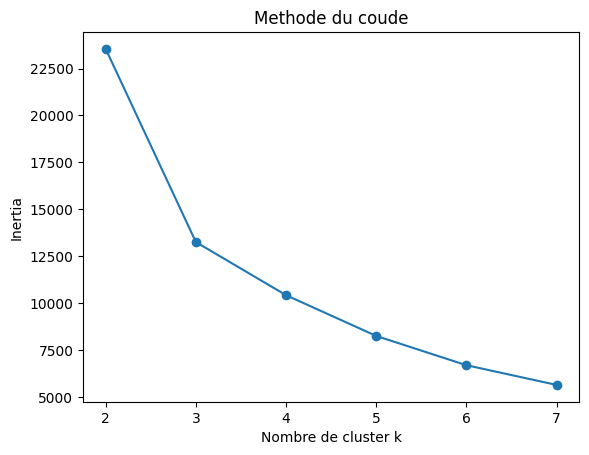

In [43]:
plt.plot(k_list, inertias, marker = 'o')

plt.xlabel('Nombre de cluster k')
plt.ylabel('Inertia')
plt.title('Methode du coude')

In [44]:
silhouette_scores = []

for k in k_list:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca_2)

    score = silhouette_score(X_pca_2, labels)

    silhouette_scores.append(score)

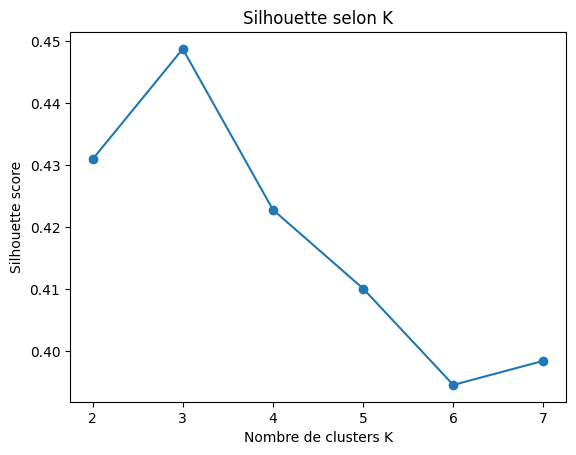

In [45]:
plt.plot(k_list, silhouette_scores, marker="o")

plt.xlabel("Nombre de clusters K")
plt.ylabel("Silhouette score")
plt.title("Silhouette selon K")

plt.show()

PCA = 4, K = 3

In [46]:
pca_final = PCA(n_components=2)

X_pca_final = pca_final.fit_transform(x_scater)

In [47]:
pca_final

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [48]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_kmeans = kmeans_final.fit_predict(X_pca_final)
cluster_kmeans

array([2, 1, 0, ..., 2, 2, 2], shape=(8950,), dtype=int32)

In [49]:
df_clean["cluster_kmeans"] = cluster_kmeans
df_clean

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,cluster_kmeans
0,C10001,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,2
1,C10002,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,1
2,C10003,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,0
3,C10004,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,2
4,C10005,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,2
...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,2
8946,C19187,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,2
8947,C19188,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,2
8948,C19189,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,2


#### Les 3 clusters ont des pourcentages > 10 %

In [50]:
pourcentage_par_cluster =df_clean.groupby('cluster_kmeans')['cluster_kmeans'].sum()/8950
pourcentage_par_cluster

cluster_kmeans
0    0.000000
1    0.271508
2    0.701006
Name: cluster_kmeans, dtype: float64

### Recherche en grille DBSCAN

X_scaled
   ↓
PCA avec plusieurs nombres de composantes
   ↓
pour chaque PCA :
    tester plusieurs eps
    tester plusieurs min_samples
   ↓
DBSCAN
   ↓
silhouette + nombre de clusters + % bruit
   ↓
tableau trié par silhouette
   ↓
choisir une combinaison
   ↓
cluster_dbscan + est_atypique_dbscan
   ↓
comparer avec K-means
   ↓
cluster_final

In [51]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

We have to compute optimal number of radius for performing DBSCAN and hence We will find nearst neighbor.



In [52]:
n_components_list = range(2, 6)

eps_list = [0.3, 0.5, 0.7, 1.0]

min_samples_list = [3, 5, 10]

results_dbscan = []

In [53]:
def check_cluster_balance(labels):
    labels_without_noise = labels[labels != -1]

    proportions = pd.Series(labels_without_noise).value_counts(
        normalize=True
    )

    return proportions

In [54]:
for n_components in n_components_list:

      #PCA
      pca = PCA (n_components=n_components)
      X_pca = pca.fit_transform(x_scater)

      for eps in eps_list:
            for min_samples in min_samples_list:

                  #dbscan
                  dbscan = DBSCAN(eps=eps, min_samples=min_samples)

                  labels = dbscan.fit_predict(X_pca)
                  noise_percent = (labels == -1).mean()*100
                  n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                  mask = labels != -1
                  X_without_noise = X_pca[mask]
                  labels_without_noise = labels[mask]
                  if n_clusters >= 2:
                        silhouette = silhouette_score(
                              X_without_noise,
                              labels_without_noise
                        )
                  else:
                        silhouette = None

                  proportions = check_cluster_balance(labels)
                  print(proportions)
                  results_dbscan.append({
                        "n_components": n_components,
                        "eps": eps,
                        "min_samples": min_samples,
                        "n_clusters": n_clusters,
                        "noise_percent": noise_percent,
                        "silhouette": silhouette
                        })

                  
results_dbscan_df = pd.DataFrame(results_dbscan)



0    0.999552
1    0.000448
Name: proportion, dtype: float64
0    0.999328
1    0.000672
Name: proportion, dtype: float64
0    0.769474
1    0.229058
2    0.001468
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0    1.0
Name: proportion, dtype: float64
0     0.755916
1     0.224077
3     0.005716
11    0.002172
9     0.001715
7     0.001601
4     0.001029
17    0.000915
13    0.000800
20    0.000686
16    0.000686
14    0.000572
6     0.000572
15    0.000457
2     0.000343
10    0.000343
8     0.000343
5     0.000343
19    0.000343
21    0.000343
12    0.000343
22    0.000343
18    0.000343
Name: proportion, dtype: float64
0     0.754345
1     0.226767
2     0.005678
4 

In [55]:
results_dbscan_df = results_dbscan_df.sort_values(
    by="silhouette",
    ascending=False
)

In [56]:
results_dbscan_df.head(10)

,n_components,eps,min_samples,n_clusters,noise_percent,silhouette
1,2,0.3,5,2,0.301676,0.421242
0,2,0.3,3,2,0.156425,0.414415
2,2,0.3,10,3,1.027933,0.387974
44,5,0.7,10,4,4.793296,0.327732
29,4,0.5,10,4,7.262570,0.320672
17,3,0.5,10,5,1.139665,0.311257
46,5,1.0,5,5,0.703911,0.302932
47,5,1.0,10,5,1.016760,0.300693
32,4,0.7,10,2,2.134078,0.298387
41,5,0.5,10,6,17.541899,0.297339


In [57]:
dbscan_candidates = results_dbscan_df[
    results_dbscan_df["noise_percent"] < 5
]

In [58]:
dbscan_candidates.head(10)

,n_components,eps,min_samples,n_clusters,noise_percent,silhouette
1,2,0.3,5,2,0.301676,0.421242
0,2,0.3,3,2,0.156425,0.414415
2,2,0.3,10,3,1.027933,0.387974
44,5,0.7,10,4,4.793296,0.327732
17,3,0.5,10,5,1.139665,0.311257
46,5,1.0,5,5,0.703911,0.302932
47,5,1.0,10,5,1.016760,0.300693
32,4,0.7,10,2,2.134078,0.298387
45,5,1.0,3,9,0.402235,0.283225
16,3,0.5,5,3,0.525140,0.239336


In [59]:
#Creating Nearest Neighbor list with respect to their index number
nbrs = NearestNeighbors(n_neighbors=10).fit(x_scater)
#Extracting euclidean distance and index numbers
distances, indices = nbrs.kneighbors(x_scater)

In [60]:
#Checking distance (1st Nearest Distance and 2nd Nearest Distance)
distances

array([[0.        , 0.23852285, 0.243229  , ..., 0.35822177, 0.38022486,
        0.38543374],
       [0.        , 0.13310871, 0.2256644 , ..., 0.27703549, 0.27815137,
        0.29589039],
       [0.        , 0.14400114, 0.17432608, ..., 0.34799333, 0.36192977,
        0.41800024],
       ...,
       [0.        , 0.14267288, 0.20770012, ..., 0.29866238, 0.30559175,
        0.32851712],
       [0.        , 0.41079656, 0.45283529, ..., 0.86474871, 0.91260774,
        1.00042113],
       [0.        , 0.48167115, 0.55387246, ..., 0.92821192, 0.92895797,
        0.93544855]], shape=(8950, 10))

In [61]:
#checking index
indices

array([[   0, 7790, 6442, ..., 8776, 8932, 5329],
       [   1, 5662, 2862, ..., 7236, 5295,  285],
       [   2,  604,  198, ..., 1414, 4665, 1443],
       ...,
       [8947, 8817, 5571, ..., 2134, 8942, 5258],
       [8948, 7135, 8899, ..., 8842, 6269, 7537],
       [8949, 8939, 5902, ..., 8077, 7167, 2841]], shape=(8950, 10))

In [62]:
#Sorting the 2nd nearest distance values in descending order
distanceDec = sorted(distances[:,2], reverse=True)
distanceDec

[np.float64(2.5035462721637165),
 np.float64(2.3341985465785187),
 np.float64(1.945055282688403),
 np.float64(1.745376233141564),
 np.float64(1.7305871860652773),
 np.float64(1.7096403723256748),
 np.float64(1.6747120649024463),
 np.float64(1.6410525848054154),
 np.float64(1.608454220175335),
 np.float64(1.6074875562379618),
 np.float64(1.5591851314553107),
 np.float64(1.5027730776227508),
 np.float64(1.4874866592741303),
 np.float64(1.476042338878636),
 np.float64(1.4722766979520088),
 np.float64(1.4647074828487963),
 np.float64(1.4615035650645798),
 np.float64(1.4585511052773048),
 np.float64(1.4378700895714982),
 np.float64(1.4278193526688432),
 np.float64(1.424298654634009),
 np.float64(1.4235604899165222),
 np.float64(1.4126984477001063),
 np.float64(1.4022800075426924),
 np.float64(1.4003482231965527),
 np.float64(1.3676250992799415),
 np.float64(1.3652403219690252),
 np.float64(1.3547254789797005),
 np.float64(1.3516402520106146),
 np.float64(1.3509585721708235),
 np.float64(1.3

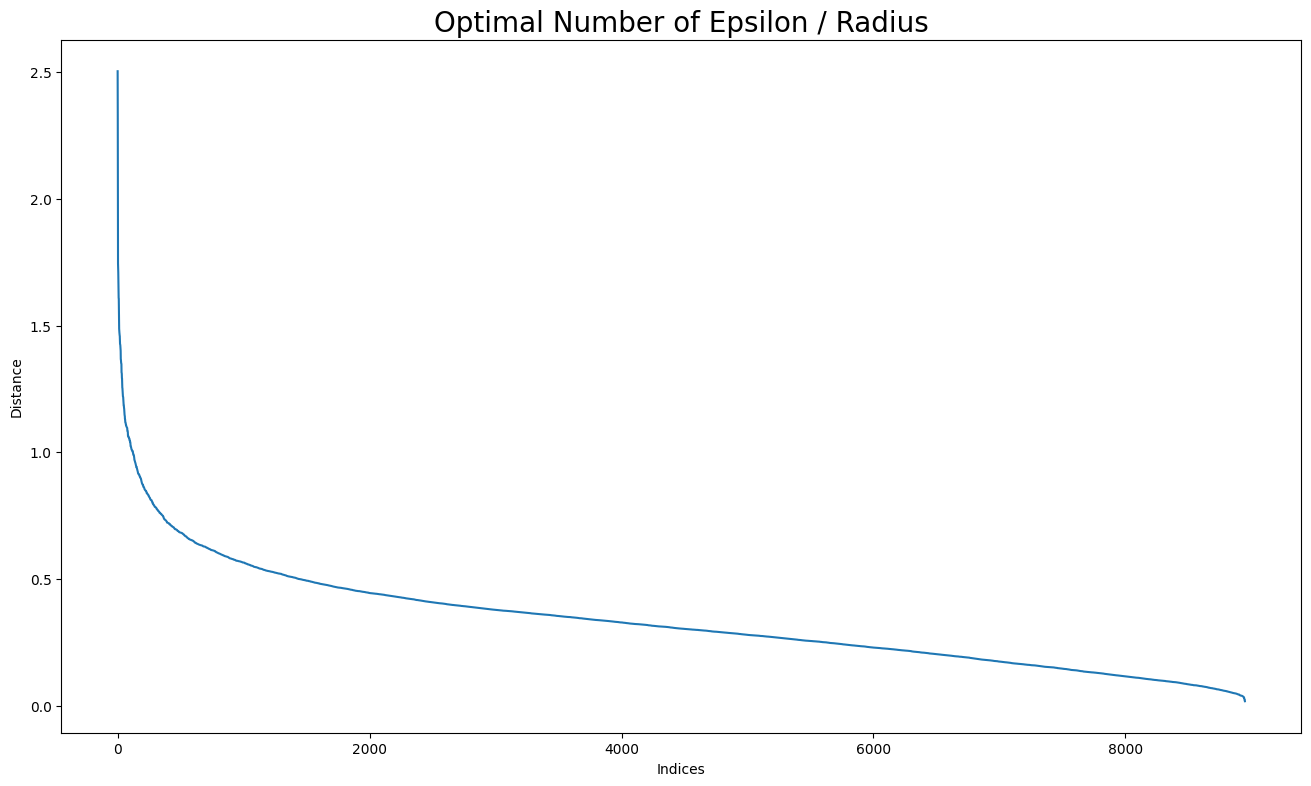

In [63]:
#Ploting 2nd nearest distance with index
plt.figure(figsize = (16,9))
plt.plot(indices[:,0],distanceDec);
plt.xlabel('Indices')
plt.ylabel('Distance')
plt.title('Optimal Number of Epsilon / Radius', fontsize = 20)
plt.show()

1 is the optimal point

In [64]:
pca_dbscan_final = PCA(n_components=5)

X_pca_dbscan_final = pca_dbscan_final.fit_transform(x_scater)

In [65]:
dbscan = DBSCAN(eps=1, min_samples=10).fit(X_pca_dbscan_final)

cluster_label = dbscan.labels_
cluster_dbscan = dbscan.fit_predict(X_pca_dbscan_final)

len(set(cluster_label))

6

In [66]:
pd.Series(dbscan.labels_).unique()

array([ 0, -1,  1,  2,  3,  4])

In [67]:
pd.Series(dbscan.labels_).value_counts()

 0    8668
-1      91
 1      64
 2      64
 3      53
 4      10
Name: count, dtype: int64

In [68]:
#Creating zeros arrays in boolean equivalent to core points of the labels
core_samples_mask = np.zeros_like(dbscan.labels_, 
                                  dtype = bool) 
core_samples_mask

array([False, False, False, ..., False, False, False], shape=(8950,))

In [69]:
#Getting the index number of the core points 
dbscan.core_sample_indices_

array([   0,    1,    2, ..., 8947, 8948, 8949], shape=(8660,))

In [70]:
#Marking core points as True in core_samples_mask
core_samples_mask[dbscan.core_sample_indices_] = True

In [71]:
#Creating labels variables
labels = dbscan.labels_
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(8950,))

In [72]:
#Computing number of clusters formed in labels
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters_

5

In [73]:
#Counting how many -1 or outliers in the labels
n_noise_ = list(labels).count(-1)
n_noise_

91

In [74]:
#Printing estimated number of cluster and noise
print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)  

Estimated number of clusters: 5
Estimated number of noise points: 91


/tmp/ipykernel_115764/4030402651.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


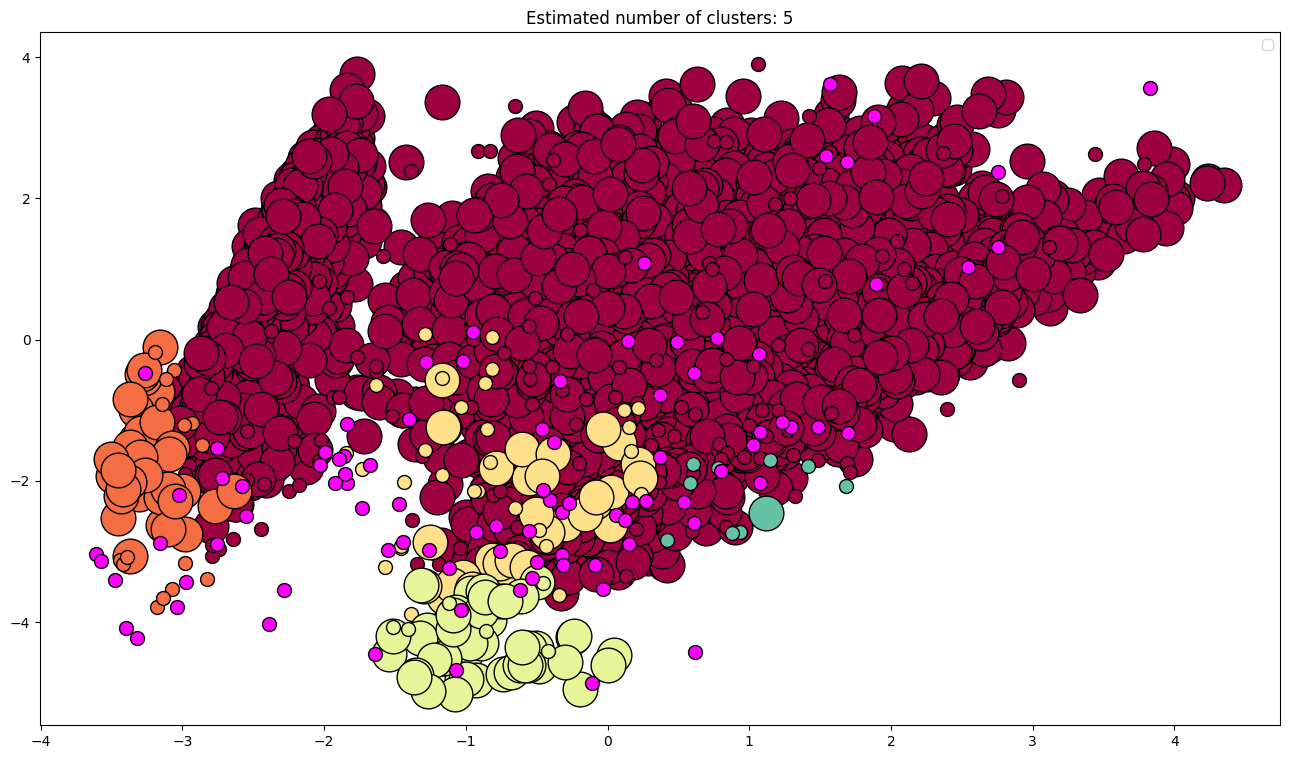

In [75]:
#Visualization of Clusters

plt.figure(figsize = (16,9)) #Fixing the size of the plot

unique_labels = set(labels) #Getting clusters labels {-1, 0, 1, 2, 3, 4, 5, 6}

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))] #Creating 8 spectral numerical codes for colors from CMYK - cyan, magenta, yellow, and key

for k, col in zip(unique_labels, colors):
  if k == -1:
    col = [1, 0, 1, 1] #This is a CMYK numerical list number of pink color.
  
  class_member_mask = (labels == k) #It is stating that mark as True for -1 and rest of are False in labels

  xy = X_pca_dbscan_final[class_member_mask & core_samples_mask] #class_member_mask is a outlier data points & core_samples_mask is a core points
  plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=25)

  xy = X_pca_dbscan_final[class_member_mask & ~core_samples_mask]
  plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),markeredgecolor='k', markersize=10)

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.legend()
plt.show()

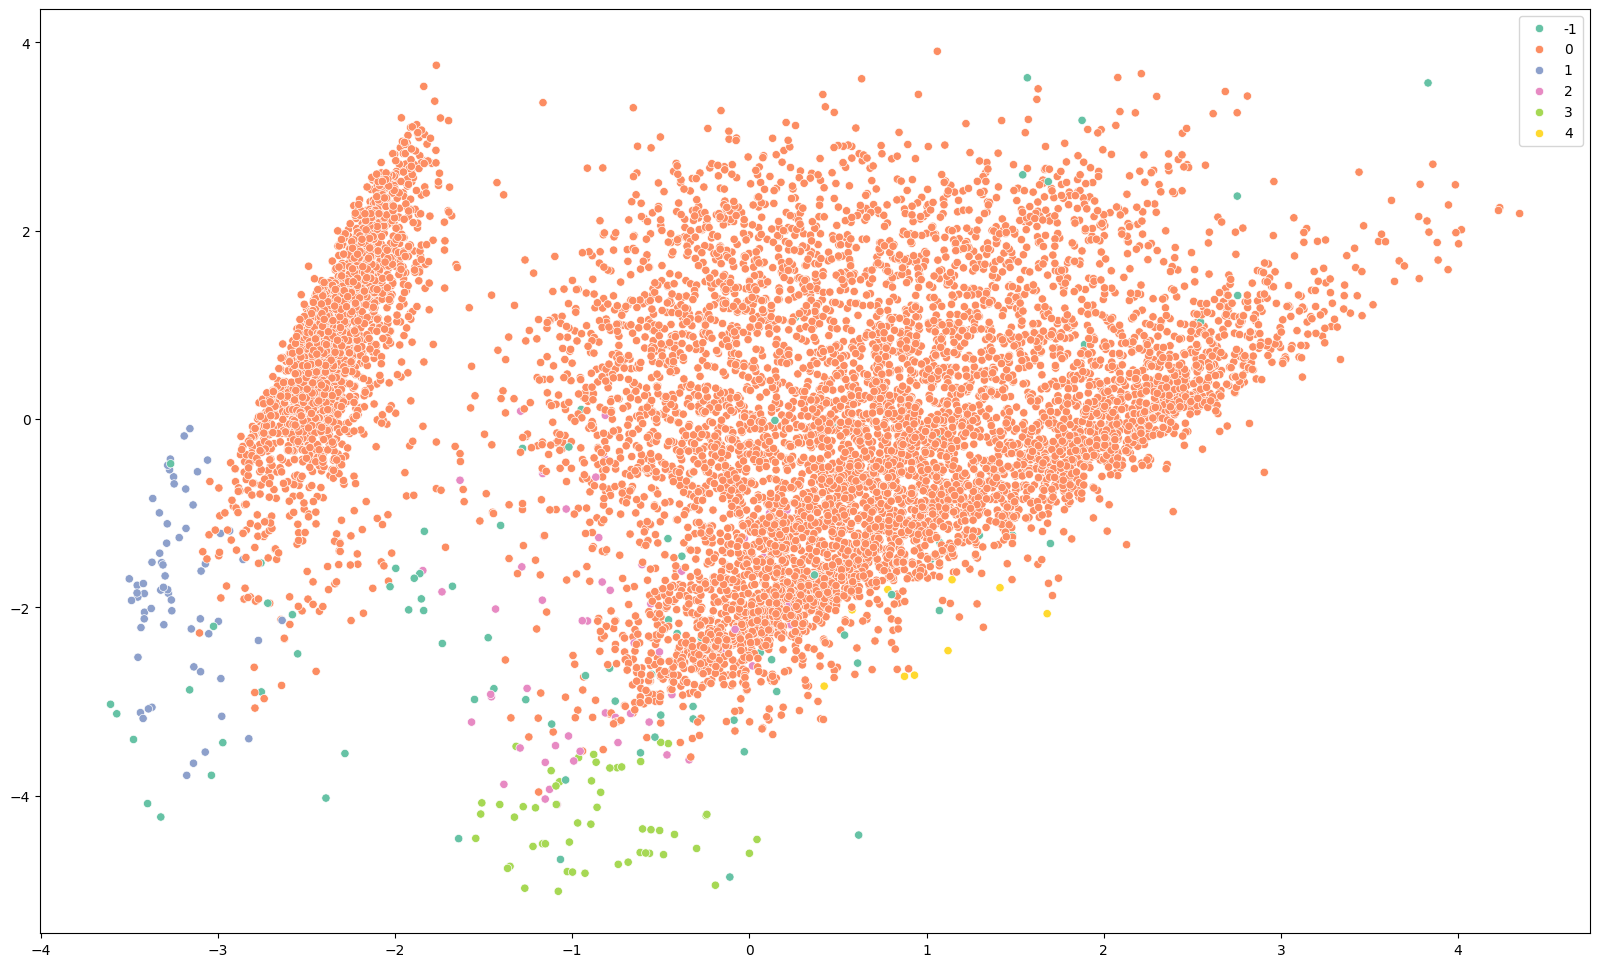

In [76]:
plt.figure(figsize=(20,12))
sns.scatterplot(x=X_pca_dbscan_final[:,0], y=X_pca_dbscan_final[:,1], hue=dbscan.labels_, palette="Set2")
plt.show()

In [77]:
# df_clean['cluster_dbscan'] = cluster_label

In [78]:
# df_clean.drop(columns='CUST_ID').groupby('cluster_dbscan').mean()

In [79]:
mask = cluster_dbscan != -1

X_dbscan_eval = X_pca_dbscan_final[mask]
labels_dbscan_eval = cluster_dbscan[mask]

silhouette_score(
    X_dbscan_eval,
    labels_dbscan_eval
)

0.30069345551762205

In [80]:
df_clean["cluster_dbscan"] = cluster_dbscan

In [81]:
df_clean["est_atypique_dbscan"] = (
    df_clean["cluster_dbscan"] == -1
)

In [82]:
df_clean.head()

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,cluster_kmeans,cluster_dbscan,est_atypique_dbscan
0,C10001,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084,2,0,False
1,C10002,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597,1,0,False
2,C10003,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742,0,0,False
3,C10004,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000,2,-1,True
4,C10005,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763,2,0,False


In [83]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [84]:
mask = cluster_dbscan != -1

X_dbscan_eval = X_pca_dbscan_final[mask]
labels_dbscan_eval = cluster_dbscan[mask]

In [85]:
silhouette_dbscan = silhouette_score(
    X_dbscan_eval,
    labels_dbscan_eval
)

davies_dbscan = davies_bouldin_score(
    X_dbscan_eval,
    labels_dbscan_eval
)

calinski_dbscan = calinski_harabasz_score(
    X_dbscan_eval,
    labels_dbscan_eval
)

In [86]:
silhouette_kmeans = silhouette_score(
    X_pca_final,
    kmeans.labels_
)

davies_kmeans = davies_bouldin_score(
    X_pca_final,
    kmeans.labels_
)

calinski_kmeans = calinski_harabasz_score(
    X_pca_final,
    kmeans.labels_
)

In [87]:
silhouette_dbscan, davies_dbscan, calinski_dbscan

(0.30069345551762205, 0.8935408102535739, 189.24526577208448)

In [88]:
silhouette_kmeans, davies_kmeans, calinski_kmeans

(0.3984141648554037, 0.7946706377367915, 9214.235637714071)

In [89]:
df_clean["cluster_final"] = df_clean["cluster_kmeans"]

In [90]:
df_scaled = pd.DataFrame(x_scater, columns=x_log.columns)
df_scaled['cluster_kmeans'] = df_clean["cluster_kmeans"]

In [91]:
r_stander = df_scaled.groupby('cluster_kmeans')[df_scaled.columns.difference(other=['cluster_kmeans'])].mean()

In [92]:
df_clean.groupby('cluster_final')[df_clean.columns.difference(other=['CUST_ID', 'cluster_final'])].mean()

,BALANCE,CASH_ADVANCE,CREDIT_LIMIT,INSTALLMENTS_PURCHASES,ONEOFF_PURCHASES,PAYMENTS,PURCHASES,cluster_dbscan,cluster_kmeans,est_atypique_dbscan
cluster_final,,,,,,,,,,
0,2266.791083,1096.993912,6531.340899,789.140411,1414.467555,2893.899180,2203.375288,-0.003843,0.0,0.003843
1,2174.726890,2007.253219,3980.955231,4.810189,19.025165,1629.684882,23.785284,0.020576,1.0,0.003292
2,334.366952,54.874316,2695.116563,318.044198,150.124189,561.505351,467.601664,0.083838,2.0,0.022314


In [93]:
r = (df_clean.groupby('cluster_final')[df_clean.columns.difference(other=['CUST_ID', 'cluster_final'])].mean())
r

,BALANCE,CASH_ADVANCE,CREDIT_LIMIT,INSTALLMENTS_PURCHASES,ONEOFF_PURCHASES,PAYMENTS,PURCHASES,cluster_dbscan,cluster_kmeans,est_atypique_dbscan
cluster_final,,,,,,,,,,
0,2266.791083,1096.993912,6531.340899,789.140411,1414.467555,2893.899180,2203.375288,-0.003843,0.0,0.003843
1,2174.726890,2007.253219,3980.955231,4.810189,19.025165,1629.684882,23.785284,0.020576,1.0,0.003292
2,334.366952,54.874316,2695.116563,318.044198,150.124189,561.505351,467.601664,0.083838,2.0,0.022314


In [94]:
df_clean[df_clean['cluster_final'] == 0].max()

CUST_ID                        C19182
BALANCE                   19043.13856
PURCHASES                    49039.57
ONEOFF_PURCHASES             40761.25
INSTALLMENTS_PURCHASES        22500.0
CASH_ADVANCE              47137.21176
CREDIT_LIMIT                  30000.0
PAYMENTS                  50721.48336
cluster_kmeans                      0
cluster_dbscan                      0
est_atypique_dbscan              True
cluster_final                       0
dtype: object

Qu’est-ce qui caractérise chaque cluster par rapport au comportement moyen de tous les clients ?
- valeur positive → le cluster utilise davantage cette variable
- valeur négative → le cluster utilise moins cette variable
- valeur proche de 0 → cette variable ne distingue pas beaucoup ce cluster

| Valeur | Interprétation                      |
| ------ | ----------------------------------- |
| `+2`   | beaucoup plus élevé que la moyenne  |
| `+1`   | plus élevé que la moyenne           |
| `0`    | proche de la moyenne                |
| `-1`   | plus faible que la moyenne          |
| `-2`   | beaucoup plus faible que la moyenne |


<Axes: ylabel='cluster_kmeans'>

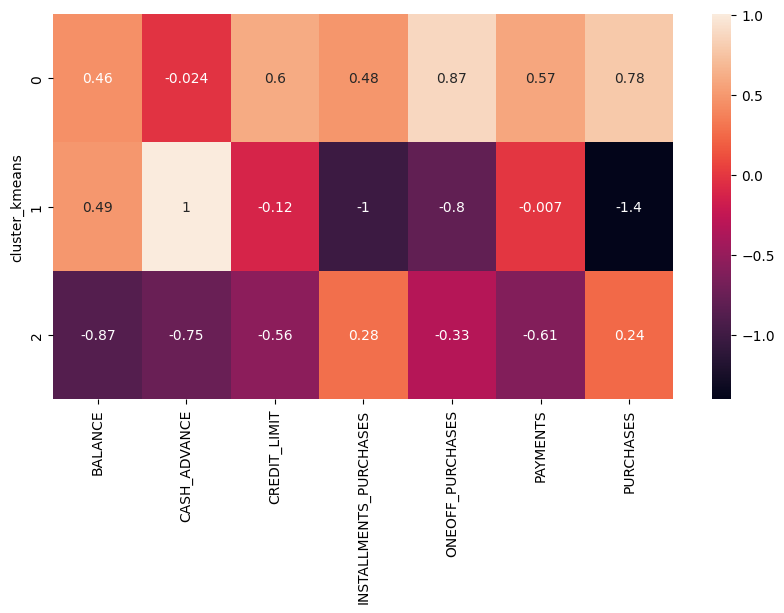

In [95]:
plt.figure(figsize=(10,5))
sns.heatmap(r_stander, annot=True)

Quelles sont les variables qui ont les valeurs les plus positives et les plus négatives ?
##### cluster 0 : 
- ONEOF_PURCHASES eleve docn achats ponctuel eleveavec un montant d'achat eleve et du paiment eleve et un cash_advance faible
- =>Le cluster 0 regroupe des clients à forte activité d'achat, caractérisés par des achats ponctuels élevés, un volume d'achats important et une limite de crédit relativement élevée.
#### cluster 1 :
- un montant d'avances des tresories plus eleve et une faiblesse d'achats
- => Le cluster 1 se caractérise principalement par un recours élevé aux avances de trésorerie (CASH_ADVANCE), tandis que les achats, les achats ponctuels et les achats en plusieurs fois sont nettement inférieurs à la moyenne.
##### cluster 2 : 
- presque tout est inferieur a la moyenne  ms, il fesant des faibles achats regles en plusieurs foix (paiement echlonne)
- =>  Le cluster 2 regroupe des clients globalement moins actifs financièrement, avec une balance, des paiements, une utilisation du cash advance et une limite de crédit inférieurs à la moyenne. Les achats restent toutefois légèrement positifs, notamment les achats en plusieurs fois.

#### Cluster 0 → Clients à forte activité d'achat

- achats élevés
- surtout achats ponctuels
- paiements élevés
- crédit élevé

#### Cluster 1 → Clients orientés cash advance
-  
-  cash advance très élevé
-  achats très faibles
-  achats ponctuels très faibles
-  achats en plusieurs fois très faibles

#### Cluster 2 → Clients à faible activité
- 
- balance faible
- cash advance faible
- paiements faibles
- crédit plus faible
- achats légèrement positifs

<Axes: ylabel='cluster_final'>

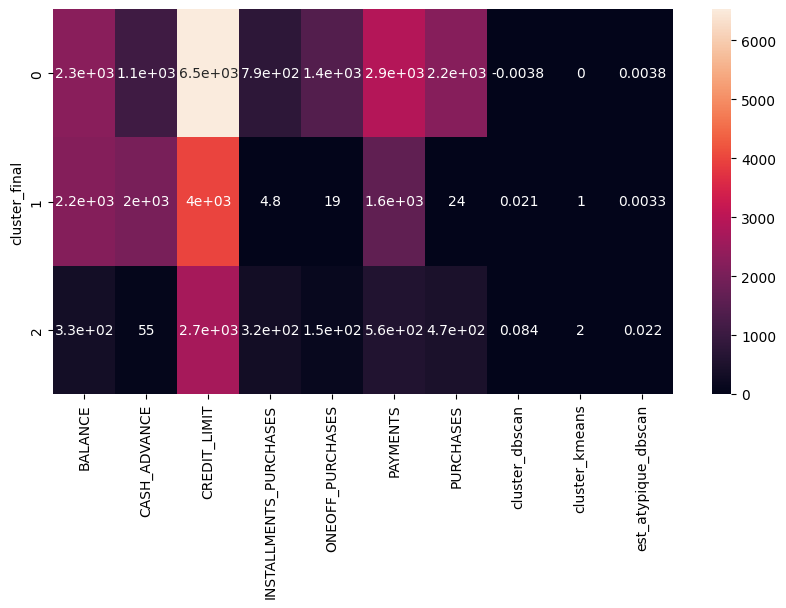

In [96]:
plt.figure(figsize=(10,5))
sns.heatmap(r, annot=True)

In [97]:
cluster_size = df_clean['cluster_final'].value_counts().sort_index()
cluster_prct = df_clean['cluster_final'].value_counts(normalize=True).sort_index() * 100

In [98]:
cluster_summary = pd.DataFrame({
    'Nombre de clients': cluster_size,
    'Pourcentage': cluster_prct
})

cluster_summary

,Nombre de clients,Pourcentage
cluster_final,,
0,3383,37.798883
1,2430,27.150838
2,3137,35.050279


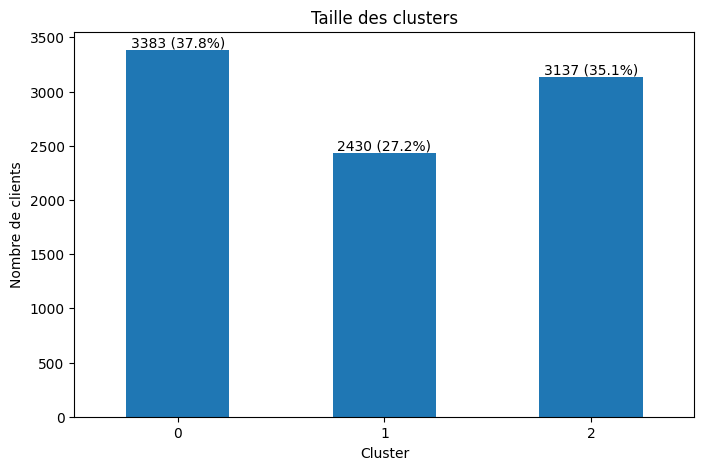

In [99]:
ax = cluster_summary['Nombre de clients'].plot(
      kind='bar', figsize=(8,5)
)
plt.title("Taille des clusters")
plt.xlabel("Cluster")
plt.ylabel("Nombre de clients")

for i, (count, pct) in enumerate(zip(cluster_summary['Nombre de clients'], cluster_summary['Pourcentage'])):
     ax.text(i, count, f'{count} ({pct:.1f}%)', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.show()

- Le cluster 0 est majoritaire avec 37.8 % des clients. Le cluster 1 représente 27.2 %, tandis que le cluster 2 représente 35.1 %. La répartition reste relativement équilibrée, aucun cluster ne concentre à lui seul une proportion excessive des clients.

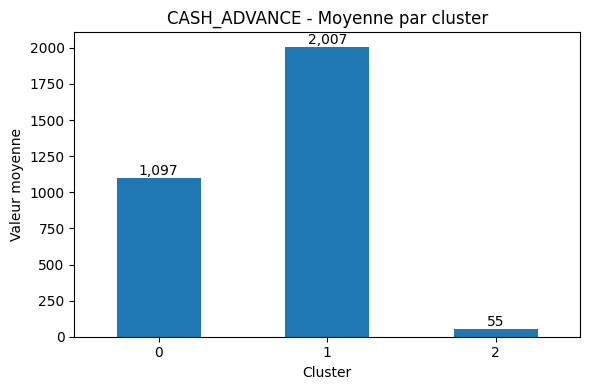

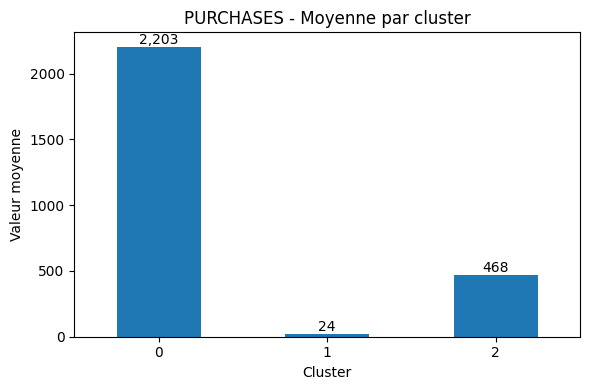

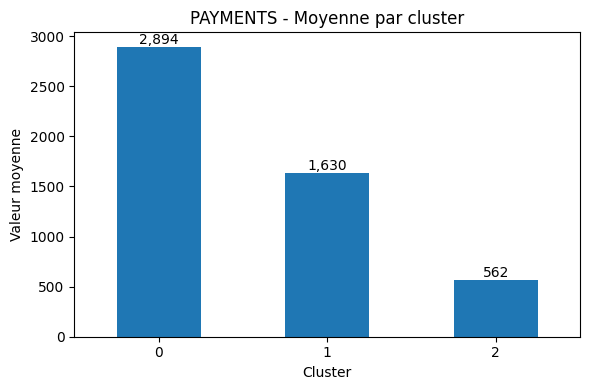

In [100]:
variables = ['CASH_ADVANCE', 'PURCHASES', 'PAYMENTS']

cluster_means = df_clean.groupby('cluster_kmeans')[variables].mean()

cluster_means
variables = ['CASH_ADVANCE', 'PURCHASES', 'PAYMENTS']

for variable in variables:
    plt.figure(figsize=(6, 4))

    values = cluster_means[variable]

    ax = values.plot(kind='bar')

    plt.title(f'{variable} - Moyenne par cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Valeur moyenne')
    plt.xticks(rotation=0)

    # Afficher les vraies valeurs sur les barres
    for i, value in enumerate(values):
        ax.text(
            i,
            value,
            f'{value:,.0f}',
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

In [101]:
df_clean.groupby('cluster_final')[df_clean.columns.difference(other=['CUST_ID', 'cluster_final'])].agg(['mean', 'median'])

BALANCE              CASH_ADVANCE               \
                      mean       median         mean       median   
cluster_final                                                       
0              2266.791083  1466.852542  1096.993912     0.000000   
1              2174.726890  1502.146132  2007.253219  1270.567396   
2               334.366952    73.100550    54.874316     0.000000   

              CREDIT_LIMIT         INSTALLMENTS_PURCHASES          \
                      mean  median                   mean  median   
cluster_final                                                       
0              6531.340899  6000.0             789.140411  390.92   
1              3980.955231  3000.0               4.810189    0.00   
2              2695.116563  2000.0             318.044198  195.00   

              ONEOFF_PURCHASES             PAYMENTS                 PURCHASES  \
                          mean  median         mean       median         mean   
cluster_final                                                                   
0                  1414.467555  780.13  2893.899180  1791.285108  2203.375288   
1                    19.025165    0.00  1629.684882   767.022356    23.785284   
2                   150.124189    0.00   561.505351   394.135239   467.601664   

                       cluster_dbscan        cluster_kmeans         \
                median           mean median           mean median   
cluster_final                                                        
0              1365.50      -0.003843    0.0            0.0    0.0   
1                 0.00       0.020576    0.0            1.0    1.0   
2               325.95       0.083838    0.0            2.0    2.0   

              est_atypique_dbscan         
                             mean median  
cluster_final                             
0                        0.003843    0.0  
1                        0.003292    0.0  
2                        0.022314    0.0

In [102]:
df_clean.groupby('cluster_final')[df_clean.columns.difference(other=['CUST_ID', 'cluster_final'])].quantile([0.25, 0.75])

/tmp/ipykernel_115764/3611749826.py:1: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  df_clean.groupby('cluster_final')[df_clean.columns.difference(other=['CUST_ID', 'cluster_final'])].quantile([0.25, 0.75])


BALANCE  CASH_ADVANCE  CREDIT_LIMIT  \
cluster_final                                                 
0             0.25   481.506330      0.000000        3500.0   
              0.75  3137.673214   1248.768609        8500.0   
1             0.25   854.947813    430.940396        1500.0   
              0.75  2817.306869   2705.653718        6000.0   
2             0.25    21.639571      0.000000        1200.0   
              0.75   434.932876      0.000000        3200.0   

                    INSTALLMENTS_PURCHASES  ONEOFF_PURCHASES     PAYMENTS  \
cluster_final                                                               
0             0.25                   35.00            262.72  1020.783293   
              0.75                 1035.28           1639.51  3348.760032   
1             0.25                    0.00              0.00   383.428009   
              0.75                    0.00              0.00  1700.062182   
2             0.25                    0.00              0.00   194.532194   
              0.75                  441.23            148.66   717.927436   

                    PURCHASES  cluster_dbscan  cluster_kmeans  \
cluster_final                                                   
0             0.25     675.79             0.0             0.0   
              0.75    2599.71             0.0             0.0   
1             0.25       0.00             0.0             1.0   
              0.75       0.00             0.0             1.0   
2             0.25     150.00             0.0             2.0   
              0.75     602.07             0.0             2.0   

                    est_atypique_dbscan  
cluster_final                            
0             0.25                  0.0  
              0.75                  0.0  
1             0.25                  0.0  
              0.75                  0.0  
2             0.25                  0.0  
              0.75                  0.0

cette verification de la mediane et de la moyene avec les quantiles 0.25 et 0.75 assurer que les interpreation sont vrais
| Cluster | Variables caractéristiques                            | Profil                     | Description                     |
| ------- | ----------------------------------------------------- | -------------------------- | -------------------------- |
| **0**   | PURCHASES ↑, ONEOFF ↑, PAYMENTS ↑, CREDIT_LIMIT ↑     | **Clients Premium** | PURCHASES et ONEOFF_PURCHASES élevé et activité de paiement importante. Ils utilisent principalement leur carte pour effectuer des achats. |
| **1**   | CASH_ADVANCE ↑, PURCHASES ↓, ONEOFF ↓, INSTALLMENTS ↓ | **Clients à Risque**  | CASH_ADVANCE est particulièrement élevé. Ces clients utilisent davantage leur carte pour obtenir des avances de trésorerie que pour effectuer des achats classiques. |
| **2**   | BALANCE ↓, CASH_ADVANCE ↓, PAYMENTS ↓, CREDIT_LIMIT ↓ | **Clients à Faible Activité**        |  Les principales dépenses et paiements sont faibles. Ils représentent des clients avec une utilisation limitée de la carte.  |


##### Creation du target

In [103]:
cluster_names = {
    0: "Clients Premium",
    1: "Clients à Risqu",
    2: "Clients à Faible Activité"
}
df_clean['target'] = df_clean['cluster_final'].map(cluster_names)

In [104]:
df_clean

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,cluster_kmeans,cluster_dbscan,est_atypique_dbscan,cluster_final,target
0,C10001,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,2,0,False,2,Clients à Faible Activité
1,C10002,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,1,0,False,1,Clients à Risqu
2,C10003,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,0,0,False,0,Clients Premium
3,C10004,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,2,-1,True,2,Clients à Faible Activité
4,C10005,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,2,0,False,2,Clients à Faible Activité
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,2,0,False,2,Clients à Faible Activité
8946,C19187,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,2,0,False,2,Clients à Faible Activité
8947,C19188,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,2,0,False,2,Clients à Faible Activité
8948,C19189,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,2,0,False,2,Clients à Faible Activité


### Feature Story 5 : Classification supervisée et évaluation des modèles

In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

In [106]:
columns_to_remove = [
    'CUST_ID',
    'target',
    'cluster_kmeans',
    'cluster_dbscan',
    'est_atypique_dbscan',
    'cluster_final'
]
X = df_clean[df_clean.columns.difference(other=columns_to_remove)]
y = df_clean['target']

In [107]:
y.value_counts(normalize=True)

target
Clients Premium              0.377989
Clients à Faible Activité    0.350503
Clients à Risqu              0.271508
Name: proportion, dtype: float64

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7160, 7), (7160,), (1790, 7), (1790,))

In [109]:
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics import classification_report_imbalanced

In [110]:
from imblearn.metrics import classification_report_imbalanced

pipeline = Pipeline(steps=[
      ('scaler', StandardScaler()),
      ('regressor', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
pipeline.fit(X_train, y_train)
pp = pipeline.predict(X_test)
print(classification_report_imbalanced(y_test, pp))

                                 pre       rec       spe        f1       geo       iba       sup

          Clients Premium       0.95      0.87      0.97      0.91      0.92      0.84       677
Clients à Faible Activité       0.87      0.91      0.93      0.89      0.92      0.84       627
          Clients à Risqu       0.87      0.92      0.95      0.90      0.94      0.87       486

              avg / total       0.90      0.90      0.95      0.90      0.92      0.85      1790



In [111]:
pipeline = Pipeline(steps=[
      ('scaler', StandardScaler()),
      ('logreg', LogisticRegression(
            C=0.1,
            max_iter=1000,
            random_state=42
            ))
])

### modèle de référence.

                           precision    recall  f1-score   support

          Clients Premium       0.95      0.87      0.91       677
Clients à Faible Activité       0.87      0.91      0.89       627
          Clients à Risqu       0.87      0.92      0.90       486

                 accuracy                           0.90      1790
                macro avg       0.90      0.90      0.90      1790
             weighted avg       0.90      0.90      0.90      1790



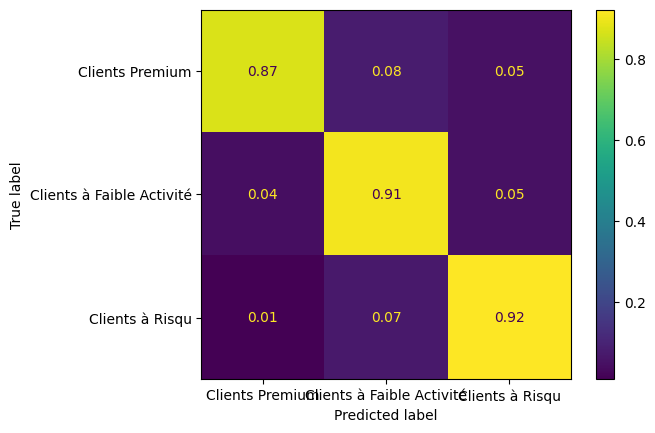

In [112]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', values_format='.2f')

### Cross-validation du modèle de base
- modèle est relativement stable entre les différents folds.

In [113]:
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
print("Scores :", cv_scores)
print("F1 macro moyen :", cv_scores.mean())
print("Écart-type :", cv_scores.std())


Scores : [0.88470838 0.89719335 0.87897731 0.87851863 0.89148194]
F1 macro moyen : 0.886175921959812
Écart-type : 0.007240792438572556


### GridSearchCV
- GridSearchCV a recherché automatiquement la combinaison d'hyperparamètres offrant le meilleur F1-score macro moyen sur 5 folds.

In [114]:
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga'],
    'logreg__max_iter': [500, 1000],
    'logreg__class_weight': [None, 'balanced']
}

/home/noha/DEVAI/CardProfiler/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/noha/DEVAI/CardProfiler/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/noha/DEVAI/CardProfiler/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' o

Meilleurs paramètres :
{'logreg__C': 10, 'logreg__class_weight': None, 'logreg__max_iter': 1000, 'logreg__penalty': 'l1', 'logreg__solver': 'saga'}
Meilleur F1 macro CV : 0.9070039025656669
                           precision    recall  f1-score   support

          Clients Premium       0.94      0.91      0.92       677
Clients à Faible Activité       0.90      0.92      0.91       627
          Clients à Risqu       0.93      0.94      0.94       486

                 accuracy                           0.92      1790
                macro avg       0.92      0.92      0.92      1790
             weighted avg       0.92      0.92      0.92      1790



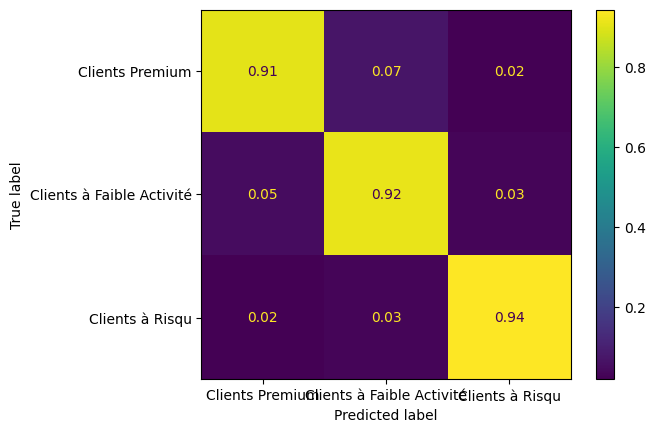

In [115]:
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(estimator=pipeline, param_grid=param_grid, return_train_score=True, n_jobs=-1, scoring='f1_macro')
gs.fit(X_train, y_train)
print("Meilleurs paramètres :")
print(gs.best_params_)
print("Meilleur F1 macro CV :", gs.best_score_)
best_model = gs.best_estimator_
y_pred_grid = best_model.predict(X_test)
print(classification_report(y_test, y_pred_grid))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_grid,
    normalize='true',
    values_format='.2f'
)

plt.show()

In [116]:
accuracy = accuracy_score(y_test, y_pred_grid)

precision = precision_score(
    y_test,
    y_pred_grid,
    average='macro'
)

recall = recall_score(
    y_test,
    y_pred_grid,
    average='macro'
)

f1 = f1_score(
    y_test,
    y_pred_grid,
    average='macro'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

Accuracy : 0.9195530726256983
Precision : 0.920008529956049
Recall : 0.9217934089659193
F1-score : 0.92075919500016


In [117]:
y_train.value_counts(normalize=True) * 100

target
Clients Premium              37.793296
Clients à Faible Activité    35.055866
Clients à Risqu              27.150838
Name: proportion, dtype: float64

### Random Forrect 

In [118]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

### Model Referentiel

In [119]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_cls = clf.predict(X_test)
accuracy_cls = accuracy_score(y_test, y_pred_cls)
print(accuracy_cls)

0.9659217877094972


### GridSearchCV

In [120]:
param_grid_clf = {
      'max_depth' : range(1, 10, 1),
      'min_samples_leaf' : range(1, 20, 2),
      'min_samples_split' : range(2, 20, 2),
      'criterion' : ['entropy', 'gini']
}

param_grid_clf_dict = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 5, 10],
    'min_samples_split': randint(2, 10),
    'bootstrap': [True, False]
}

rd_clf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_grid_clf_dict, n_iter=10, cv=5, random_state=42, n_jobs=-1)
gs_clf = GridSearchCV(estimator=clf, param_grid=param_grid_clf, cv=5, n_jobs=-1)
gs_clf.fit(X_train, y_train)
rd_clf.fit(X_train, y_train)
print('best accuracy GS', gs_clf.best_score_) 
print('best model gs', gs_clf.best_estimator_) 
print('best accuracy rf', rd_clf.best_score_) 
print('best model rf', rd_clf.best_estimator_) 

best accuracy GS 0.9663407821229051
best model gs RandomForestClassifier(criterion='entropy', max_depth=9, min_samples_split=6,
                       random_state=42)
best accuracy rf 0.9689944134078212
best model rf RandomForestClassifier(bootstrap=False, min_samples_split=6, n_estimators=152,
                       random_state=42)


### Support Vector Machine(SVM) Classifier

In [121]:
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

In [123]:
svm = SVC(kernel='linear', C=1)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_cm = confusion_matrix(y_test, y_pred_svm)
print(svm_cm)

[[622  39  16]
 [ 50 562  15]
 [  8  11 467]]


In [125]:
svm_acc

0.9223463687150838

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred_dtc =dtc.predict(X_test)
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(accuracy_dtc)

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}
gd_dtc = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5)
gd_dtc.fit(X_train, y_train)
print(gd_dtc.best_score_)
print(gd_dtc.best_estimator_)

0.9336592178770949
DecisionTreeClassifier(max_depth=9, min_samples_leaf=3, random_state=42)


In [ ]:
models_references = {
     'LogisticRegression' : (
            LogisticRegression(C=0.1, max_iter=1000, random_state=42)
            ),
      'RandomForestClassifier' : (
            RandomForestClassifier(random_state=42)
           ),
      'SVC' : (
                 SVC(kernel='linear', C=1)
           )
}

models_GSCV = {
     'LogisticRegression' : (
                 LogisticRegression(random_state=42), 
                 {
                  'logreg__C': [0.01, 0.1, 1, 10],
                  'logreg__penalty': ['l1', 'l2'],
                  'logreg__solver': ['liblinear', 'saga'],
                  'logreg__max_iter': [500, 1000],
                  'logreg__class_weight': [None, 'balanced']    
                 }
           ),
      'RandomForestClassifier' : (
                 RandomForestClassifier( random_state=42),
                 {
                  'logreg__max_depth' : range(1, 10, 1),
                  'logreg__min_samples_leaf' : range(1, 20, 2),
                  'logreg__min_samples_split' : range(2, 20, 2),
                  'logreg__criterion' : ['entropy', 'gini']   
                 }
           ),
      'SVC':(
                 SVC(random_state=42),
                 {
                  'logreg__max_depth': range(1, 10, 1),
                  'logreg__min_samples_leaf': range(1, 20, 2),
                  'logreg__min_samples_split': range(2, 20, 2),
                  'logreg__criterion': ["entropy", "gini"]   
                 }
            )
}

In [144]:
results = []
results_cv = []

In [145]:
for models_name, (model) in models_references.items():
      pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('logreg', model)
      ])
      pipeline.fit(X_train, y_train)
      y_pred = pipeline.predict(X_test)
      results.append({
            models_name : [{"accuracy" : accuracy_score(y_test, y_pred)},{"precision": precision_score(y_test, y_pred, average='macro')}, {"f1_score" : f1_score(y_test, y_pred, average='macro')}]
      })
display(results)

[{'LogisticRegression': [{'accuracy': 0.8977653631284916},
   {'precision': 0.896917637018984},
   {'f1_score': 0.8976571460333477}]},
 {'RandomForestClassifier': [{'accuracy': 0.9659217877094972},
   {'precision': 0.967197041008431},
   {'f1_score': 0.9662540019373701}]},
 {'SVC': [{'accuracy': 0.924022346368715},
   {'precision': 0.9240075758824261},
   {'f1_score': 0.9254252791599152}]}]

In [146]:
for models_name, (model, params) in models_GSCV.items():
      pipeline = Pipeline(steps=[
                  ('scaler', StandardScaler()),
                  ('logreg', model)
            ])
      gs = GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1)
      gs.fit(X_train, y_train)
      best_model = gs.best_estimator_
      best_score = gs.best_score_
      results_cv.append({
            models_name : [{"model" : models_name},{"best_model" : best_model},{"score": best_score}]
            })
display(results_cv)

ValueError: Invalid parameter 'logreg' for estimator LogisticRegression(). Valid parameters are: ['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'].